In [4]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.predictor.xwt import XWT

In [5]:
era5_dynamic = xr.open_dataset("/workspaces/BlueMath_Course_Corvallis/toolkit/data/data_mslp.nc")
era5_dynamic

<xarray.Dataset> Size: 736MB
Dimensions:    (time: 30642, latitude: 60, longitude: 100)
Coordinates:
  * time       (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-11-22
  * latitude   (latitude) float32 240B 79.62 78.62 77.62 ... 22.62 21.62 20.62
  * longitude  (longitude) float32 400B -79.62 -78.62 -77.62 ... 18.38 19.38
Data variables:
    mslp       (time, latitude, longitude) float32 735MB ...

In [ ]:
pca = PCA(n_components=0.9)
kma = KMA(num_clusters=36, seed=42)

xwt = XWT(steps={"pca": pca, "kma": kma})
xwt.fit(
    data=era5_dynamic,
    fit_params={
        "pca": {
            "vars_to_stack": ['mslp'],
            "coords_to_stack": ["latitude", "longitude"],
            "pca_dim_for_rows": "time",
            "value_to_replace_nans": {"msl": 101325.0, "msl_gradient": 0.0},
        },
        "kma": {
            "normalize_data": False,
            "min_number_of_points": 25,
            "max_number_of_iterations": 100,
        },
    },
    variable_to_sort_bmus="mslp",
)

# xwt._exclude_attributes = []  # To save data used for fitting
# xwt.save_model("outputs/dwt_model_aveiro.pkl")

2026-09-23 09:33:33,958 - PCA - WARNING - Using 6000 out of 6000 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/dwt_model_aveiro.pkl'

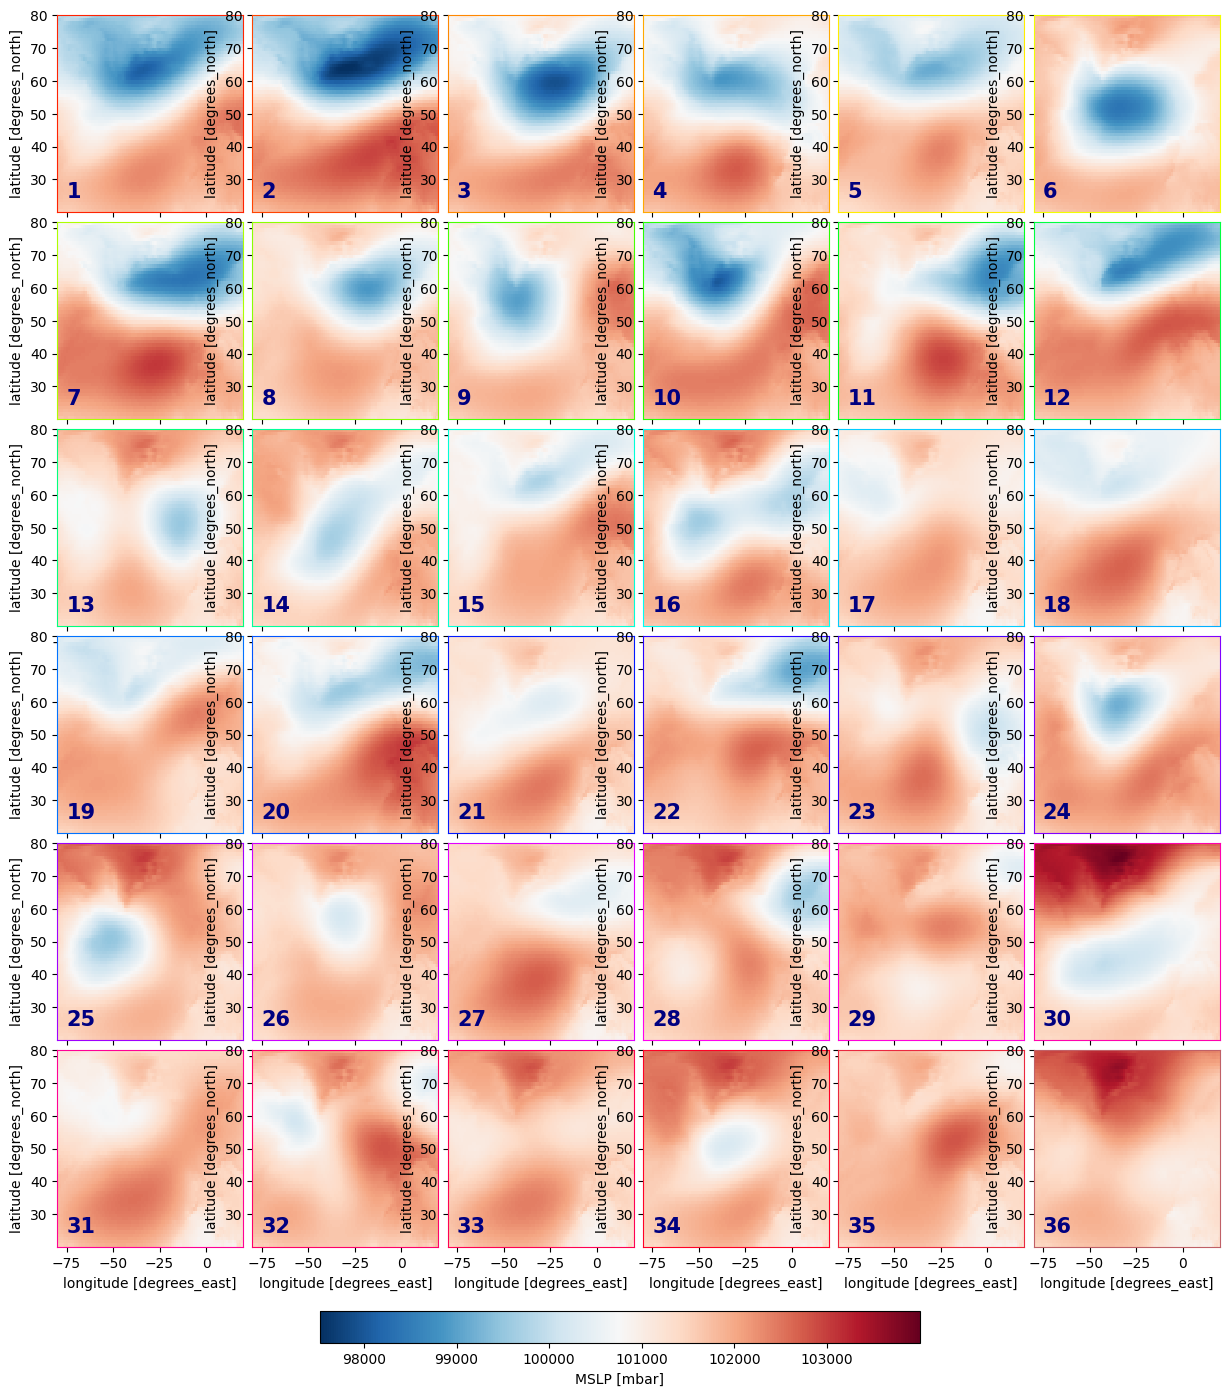

In [9]:
xwt.plot_xwts(var_to_plot='mslp')

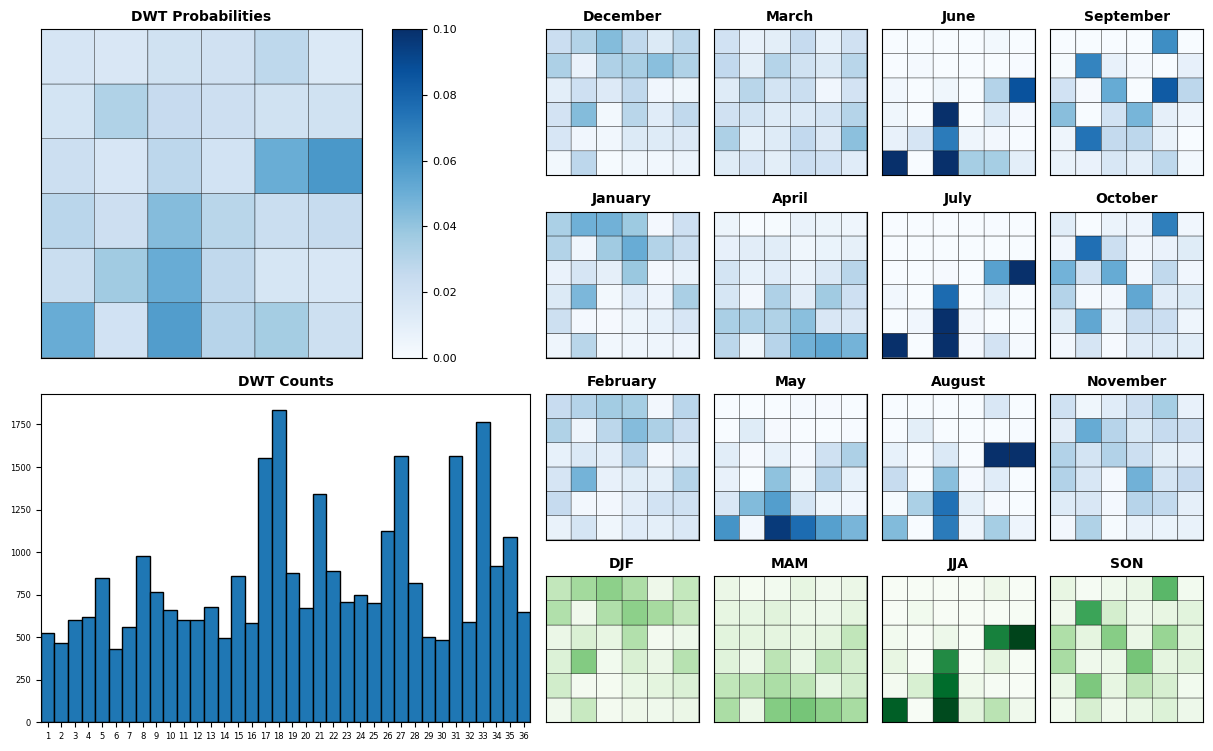

In [11]:
xwt.plot_dwts_probs()

<Axes: >

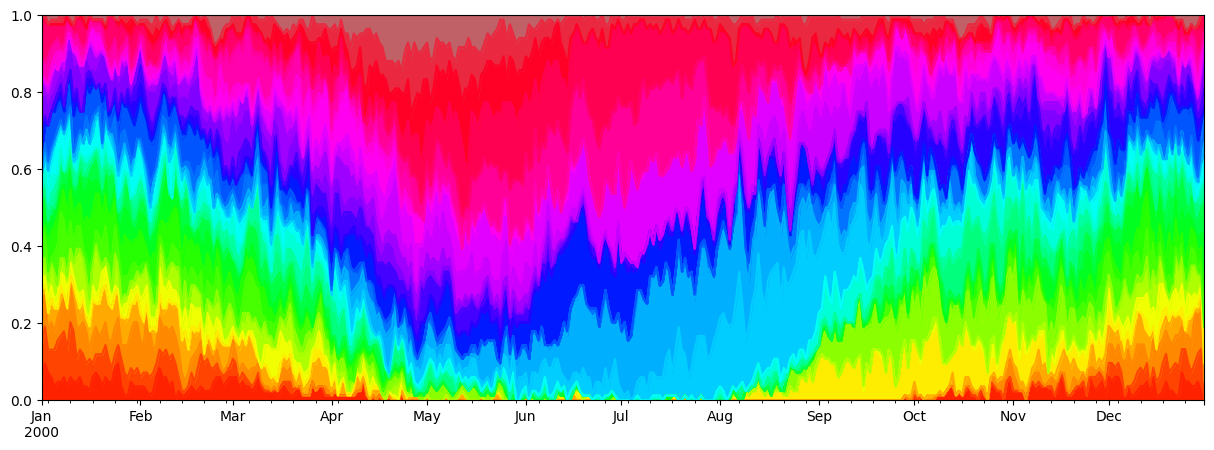

In [12]:
xwt.plot_perpetual_year()

In [15]:
xwt.kma_bmus

,kma_bmus
1940-01-01,6
1940-01-02,6
1940-01-03,6
1940-01-04,6
1940-01-05,6
...,...
2023-11-18,15
2023-11-19,15
2023-11-20,5
2023-11-21,5


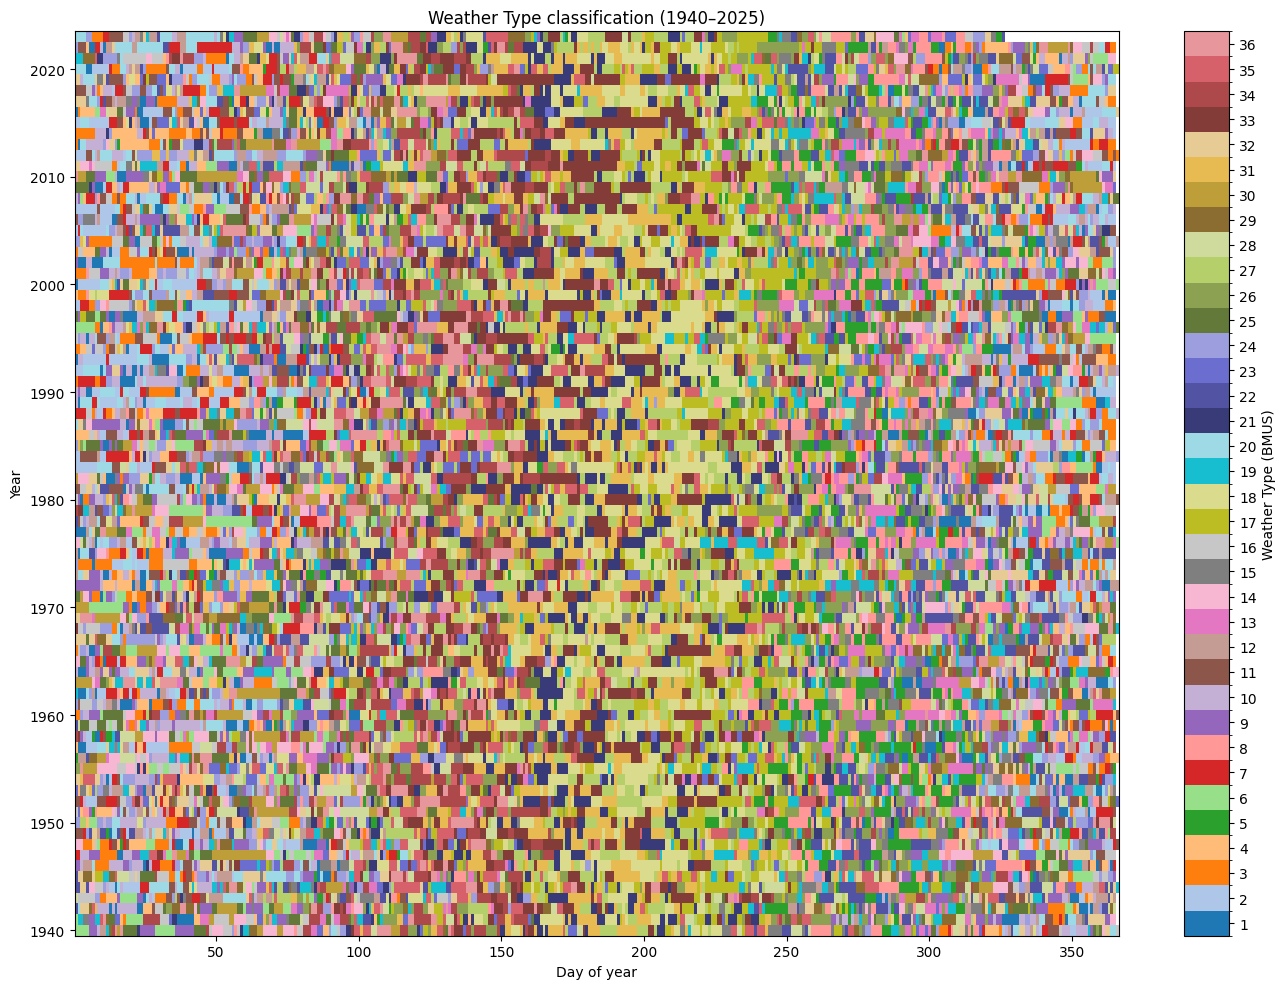

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

df = xwt.kma_bmus.copy()
df['year'] = df.index.year
df['doy'] = df.index.dayofyear

# Rejilla año x día-del-año
grid = df.pivot(index='year', columns='doy', values='kma_bmus')

# --- Paleta de 36 colores ---
# Intenta usar la paleta propia de BlueMath; si no la encuentras, usa un fallback categórico robusto
try:
    from bluemath_tk.plotting.colors import colors_awt   # <- ajusta la ruta si no es esta
    colors = colors_awt(36)
except ImportError:
    base1 = plt.get_cmap('tab20')
    base2 = plt.get_cmap('tab20b')
    colors = [base1(i) for i in range(20)] + [base2(i) for i in range(16)]

cmap = ListedColormap(colors)
bounds = np.arange(0.5, 37.5, 1)   # centra cada entero 1..36 en su propio color
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, norm=norm, shading='auto')

ax.set_xlabel('Day of year')
ax.set_ylabel('Year')
ax.set_title('Weather Type classification (1940–2025)')

cbar = fig.colorbar(im, ax=ax, ticks=range(1, 37))
cbar.set_label('Weather Type (BMUS)')

plt.tight_layout()
plt.show()